# Configurações, Caminhos e Importações

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import glob
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from google.colab import drive

# Seeds para reprodutibilidade
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

drive.mount('/content/drive')

# --- CONFIGURAÇÃO DE CAMINHOS ---
dataset_path = '/content/drive/MyDrive/TCC/PKG - Osteosarcoma Tumor Assessment'
csv_path = '/content/drive/MyDrive/TCC/ML_Features_1144.csv'
save_model_path = '/content/drive/MyDrive/TCC/Modelos_Osteosarcoma'

os.makedirs(save_model_path, exist_ok=True)

# NOMES PARA A RESNET50
checkpoint_path = os.path.join(save_model_path, 'melhor_modelo_ResNet50_3classes_CLAHE_temp.keras')
final_model_name = os.path.join(save_model_path, 'ResNet50_Osteosarcoma_3classes_CLAHE_Final.keras')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100

Mounted at /content/drive


# Função CLAHE (YUV) + Pré-processamento ResNet

In [ ]:
def apply_clahe_resnet(image):
    """
    Converte RGB -> YUV, aplica CLAHE no canal Y, retorna para RGB e
    aplica o preprocess_input específico da ResNet50.
    """
    img_uint8 = image.astype('uint8')

    # 1. Converter de RGB para YUV
    yuv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YUV)

    # 2. Aplicar CLAHE no canal de Luminância (Y)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    yuv[:,:,0] = clahe.apply(yuv[:,:,0])

    # 3. Converter de volta para RGB
    img_final = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    # 4. Aplicar o preprocessamento da ImageNet específico para a ResNet50
    img_preprocessed = preprocess_input(img_final.astype('float32'))

    return img_preprocessed

# Mapeamento e Agrupamento das 3 Classes

In [ ]:
print("Iniciando carregamento e agrupamento (3 Classes)...")
df_original = pd.read_csv(csv_path)

# Criando cópia
df_copia = df_original.copy()

# ==============================================================================
# ALTERAÇÃO DO DATASET: Mesclando 'viable: non-viable' em 'Viable'
# ==============================================================================
df_copia['classification'] = df_copia['classification'].replace('viable: non-viable', 'Viable')

print("\nDistribuição de Classes para a ResNet50:")
print(df_copia['classification'].value_counts())

all_image_paths = glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)
all_image_paths += glob.glob(os.path.join(dataset_path, '**', '*.JPG'), recursive=True)

normalized_path_lookup = {}
for p in all_image_paths:
    base = os.path.basename(p)
    name_no_ext = os.path.splitext(base)[0]
    norm_name = name_no_ext.lower().replace(" ", "").replace("-", "").replace("_", "")
    normalized_path_lookup[norm_name] = p

def get_full_path_robust(image_name):
    if pd.isna(image_name): return None
    norm_csv_name = str(image_name).lower().replace(" ", "").replace("-", "").replace("_", "")
    return normalized_path_lookup.get(norm_csv_name)

df_copia['full_path'] = df_copia['image.name'].apply(get_full_path_robust)
df_final = df_copia.dropna(subset=['full_path']).copy()

print(f"\nTotal de imagens mapeadas: {len(df_final)} / 1144")

Iniciando carregamento e agrupamento (3 Classes)...

Distribuição de Classes para a ResNet50:
classification
Non-Tumor           536
Viable              345
Non-Viable-Tumor    263
Name: count, dtype: int64

Total de imagens mapeadas: 1144 / 1144


# Divisão e Geradores

In [ ]:
# Divisão (70/15/15)
train_df, temp_df = train_test_split(
    df_final, train_size=0.7, stratify=df_final['classification'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.5, stratify=temp_df['classification'], random_state=RANDOM_SEED
)

# Gerador com CLAHE e Pré-processamento acoplado
datagen = ImageDataGenerator(preprocessing_function=apply_clahe_resnet)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    val_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    test_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 800 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.


# Arquitetura ResNet50 e Treinamento

In [ ]:
def build_model_osteo_resnet(num_classes=3):

    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model_osteo_resnet(num_classes=3)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando Treinamento (ResNet50 | 3 Classes | CLAHE YUV)...")
history = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

model.save(final_model_name)
print(f"Treinamento concluído! Modelo salvo em: {final_model_name}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Iniciando Treinamento (ResNet50 | 3 Classes | CLAHE YUV)...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.5410 - loss: 1.1301 
Epoch 1: val_loss improved from None to 0.39953, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_ResNet50_3classes_CLAHE_temp.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_ResNet50_3classes_CLAHE_temp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 710s 28s/step - accuracy: 0.6587 - loss: 0.8873 - val_accuracy: 0.8430 - val_loss: 0.3995
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8301 - loss: 0.4800
Epoch 2: val_loss improved from 0.39953 to 0.33722, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_ResNet50_3classes_CLAHE_temp.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_ResNet50_3classes_CLAHE_temp.keras
25/25 ━━

# Avaliação Final

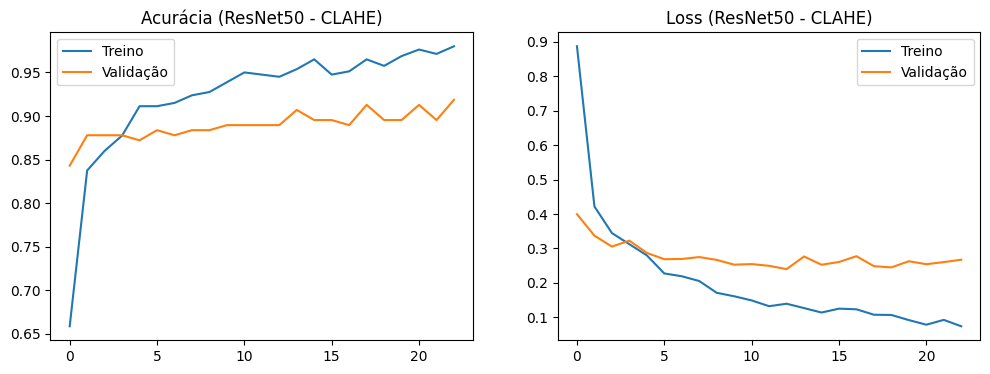

6/6 ━━━━━━━━━━━━━━━━━━━━ 92s 17s/step

--- RELATÓRIO DE CLASSIFICAÇÃO (ResNet50) ---
                  precision    recall  f1-score   support

       Non-Tumor     0.9277    0.9506    0.9390        81
Non-Viable-Tumor     0.9211    0.8974    0.9091        39
          Viable     0.9216    0.9038    0.9126        52

        accuracy                         0.9244       172
       macro avg     0.9234    0.9173    0.9202       172
    weighted avg     0.9243    0.9244    0.9243       172



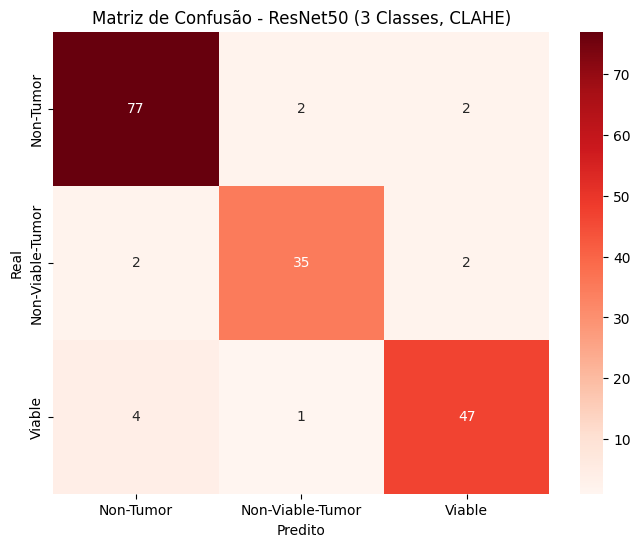

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Gráficos
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia (ResNet50 - CLAHE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss (ResNet50 - CLAHE)')
plt.legend()
plt.show()

# Predição
test_gen.reset()
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Relatório
print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (ResNet50) ---")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# Matriz
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - ResNet50 (3 Classes, CLAHE)')
plt.show()